## Heart disease research

In [1]:
import numpy as np
import pandas as pd

In [32]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
# load data
heart = pd.read_csv('heart_disease.csv')

In [19]:
heart.head()

,age,sex,trestbps,chol,cp,exang,fbs,thalach,heart_disease
0,63.0,male,145.0,233.0,typical angina,0.0,1.0,150.0,absence
1,67.0,male,160.0,286.0,asymptomatic,1.0,0.0,108.0,presence
2,67.0,male,120.0,229.0,asymptomatic,1.0,0.0,129.0,presence
3,37.0,male,130.0,250.0,non-anginal pain,0.0,0.0,187.0,absence
4,41.0,female,130.0,204.0,atypical angina,0.0,0.0,172.0,absence


- trestbps: resting blood pressure in mm Hg
- chol: serum cholesterol in mg/dl
- cp: chest pain type ('typical angina', 'atypical angina', 'non-anginal pain', or 'asymptomatic')
- exang: whether the patient experiences exercise-induced angina (1: yes; 0: no)
- fbs: whether the patient’s fasting blood sugar is >120 mg/dl (1: yes; 0: no)
- thalach: maximum heart rate achieved in exercise test

In [2]:
yes_hd = heart[heart.heart_disease == 'presence']
no_hd = heart[heart.heart_disease == 'absence']

### Cholesterol Analysis

In [3]:
chol_hd = yes_hd.chol

In general, total cholesterol over 240 mg/dl is considered “high” (and therefore unhealthy)

In [6]:
print(np.mean(chol_hd))

251.4748201438849


hypotheses:

Null: People with heart disease have an average cholesterol level equal to 240 mg/dl

Alternative: People with heart disease have an average cholesterol level that is greater than 240 mg/dl

In [7]:
from scipy.stats import ttest_1samp

In [12]:
tstat, pval = ttest_1samp(chol_hd, 240)
print(pval/2)

0.0035411033905155707


p-value = 0.0035 < 0.05, suggesting that heart disease patients have an average cholesterol level significantly higher than 240 mg/dl.

In [45]:
chol_no_hd = no_hd.chol
print(np.mean(chol_no_hd))

242.640243902439


In [14]:
tstat, pval = ttest_1samp(chol_no_hd, 240)
print(pval/2)

0.26397120232220506


### Fasting Blood Sugar Analysis

In [16]:
num_patients = len(heart)
print(num_patients)

303


In [21]:
num_highfbs_patients = np.sum(heart.fbs)
print(num_highfbs_patients)

45.0


By some estimates, about 8% of the U.S. population had diabetes (diagnosed or undiagnosed) in 1988 when this data was collected. 

While there are multiple tests that contribute to a diabetes diagnosis, fasting blood sugar levels greater than 120 mg/dl can be indicative of diabetes (or at least, pre-diabetes). 

In [22]:
num_patients * 0.08

24.240000000000002

estimate 24 people to have diabetes, almost half the number with fbs > 120 in the sample (45)

hypotheses:

Null: This sample was drawn from a population where 8% of people have fasting blood sugar > 120 mg/dl

Alternative: This sample was drawn from a population where more than 8% of people have fasting blood sugar > 120 mg/dl

In [29]:
from scipy.stats import binomtest

In [31]:
pval = binomtest(45, num_patients, 0.08, alternative = 'greater')
print(pval)

BinomTestResult(k=45, n=303, alternative='greater', statistic=0.1485148514851485, pvalue=4.689471951448875e-05)


p << 0.05, this sample likely comes from a population where more than 8% of people have fbs > 120 mg/dl.

### Predictors of Heart Disease

<Axes: xlabel='heart_disease', ylabel='thalach'>

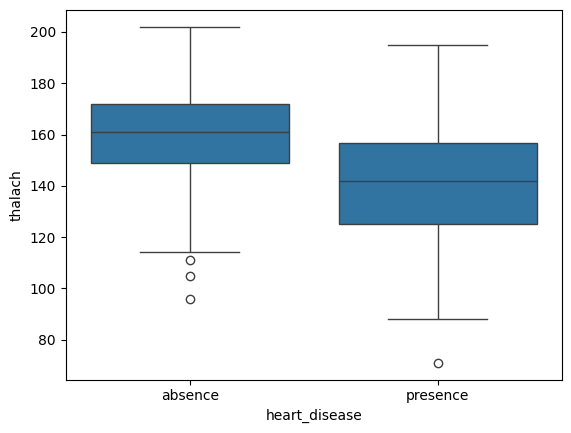

In [33]:
sns.boxplot(x=heart.heart_disease, y=heart.thalach)

patients diagnosed with heart disease generally had a lower maximum heart rate during their exercise test.

In [34]:
thalach_hd = yes_hd.thalach
thalach_no_hd = no_hd.thalach

In [35]:
mn_diff = np.mean(thalach_hd) - np.mean(thalach_no_hd)
print(mn_diff)

md_diff = np.median(thalach_hd) - np.median(thalach_no_hd)
print(md_diff)

-19.11905597473242
-19.0


hypotheses:

- Null: The average thalach for a person with heart disease is equal to the average thalach for a person without heart disease.
- Alternative: The average thalach for a person with heart disease is NOT equal to the average thalach for a person without heart disease.

In [36]:
from scipy.stats import ttest_ind

In [37]:
tstat, pval = ttest_ind(thalach_hd, thalach_no_hd)
print(pval)

3.456964908430172e-14


p << 0.05, there is a significant difference in thalach for people with heart disease compared to people without heart disease.

<Axes: xlabel='heart_disease', ylabel='age'>

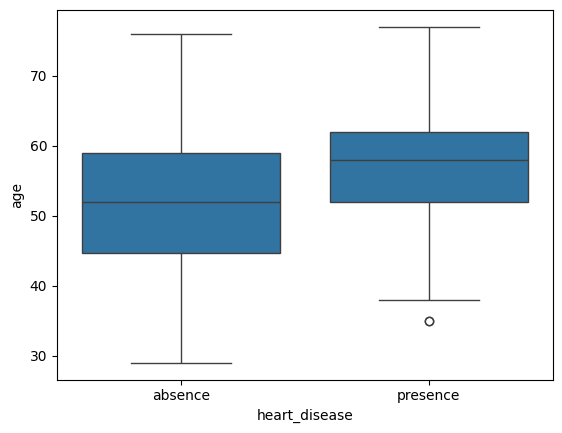

In [38]:
sns.boxplot(x=heart.heart_disease, y=heart.age)

In [39]:
age_hd = yes_hd.age
age_no_hd = no_hd.age

In [40]:
tstat, pval = ttest_ind(age_hd, age_no_hd)
print(pval)

8.955636917529706e-05


<Axes: xlabel='heart_disease', ylabel='trestbps'>

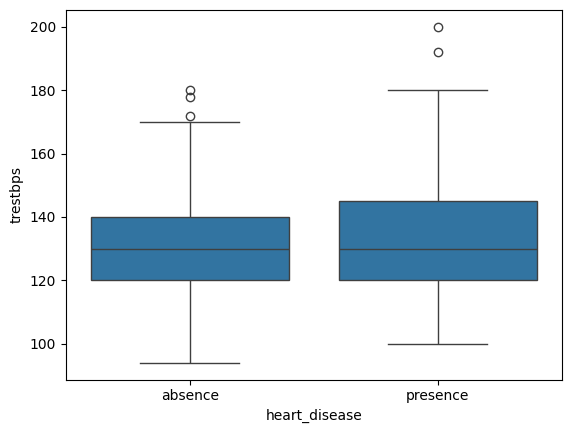

In [41]:
sns.boxplot(x=heart.heart_disease, y=heart.trestbps)

In [42]:
trestbps_hd = yes_hd.trestbps
trestbps_no_hd = no_hd.trestbps

In [43]:
tstat, pval = ttest_ind(trestbps_hd, trestbps_no_hd)
print(pval)

0.008548268928594928


<Axes: xlabel='heart_disease', ylabel='chol'>

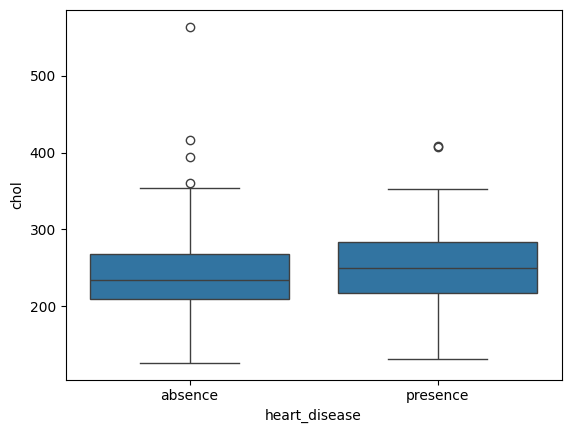

In [44]:
sns.boxplot(x=heart.heart_disease, y=heart.chol)

In [46]:
tstat, pval = ttest_ind(chol_hd, chol_no_hd)
print(pval)

0.13914167020436527


Using a 0.05 significance threshold, both age (p = 8.955636917529706e-05) and trestbps (p = 0.008548268928594928) are significantly associated with heart disease. chol is not significantly associated with heart disease

### Chest Pain and Max Heart Rate

<Axes: xlabel='cp', ylabel='thalach'>

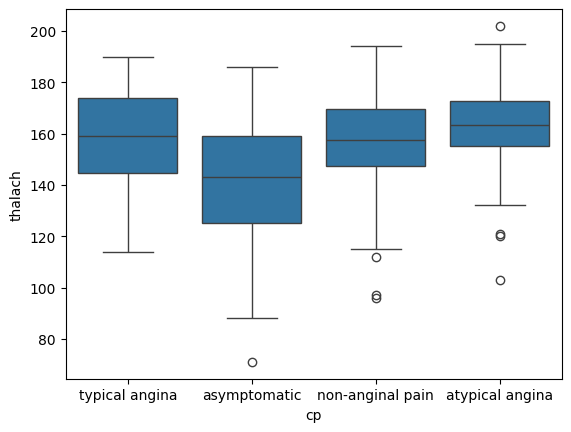

In [47]:
sns.boxplot(x=heart.cp, y=heart.thalach)

In [48]:
thalach_typical = heart.thalach[heart.cp == 'typical angina']
thalach_asymptom = heart.thalach[heart.cp == 'asymptomatic']
thalach_nonangin = heart.thalach[heart.cp == 'non-anginal pain']
thalach_atypical = heart.thalach[heart.cp == 'atypical angina']

hypotheses:

- Null: People with typical angina, non-anginal pain, atypical angina, and asymptomatic people all have the same average thalach.
- Alternative: People with typical angina, non-anginal pain, atypical angina, and asymptomatic people do not all have the same average thalach.

In [49]:
from scipy.stats import f_oneway

In [50]:
fstat, pval = f_oneway(thalach_typical, thalach_asymptom, thalach_nonangin, thalach_atypical)
print(pval)

1.9065505247705008e-10


there is at least one pair of chest pain types (cp) for which people with those pain types have significantly different average max heart rates during exercise (thalach)

In [51]:
# Tukey’s Range Test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [52]:
tukey_results = pairwise_tukeyhsd(heart.thalach, heart.cp, 0.05)
print(tukey_results)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    asymptomatic  atypical angina  21.7394    0.0  12.7442 30.7347   True
    asymptomatic non-anginal pain  14.7264    0.0   7.2583 22.1945   True
    asymptomatic   typical angina   15.276 0.0081   2.9707 27.5812   True
 atypical angina non-anginal pain   -7.013 0.2481 -16.7587  2.7327  False
 atypical angina   typical angina  -6.4635 0.6213 -20.2702  7.3432  False
non-anginal pain   typical angina   0.5495 0.9995 -12.3145 13.4136  False
-------------------------------------------------------------------------


For any pair where “Reject” is “True”, we conclude that people with those chest pain types have significantly different maximum heart rates during exercise. 

### Heart Disease and Chest Pain

In [54]:
# create contingency table
Xtab = pd.crosstab(heart.cp, heart.heart_disease)
print(Xtab)

heart_disease     absence  presence
cp                                 
asymptomatic           39       105
atypical angina        41         9
non-anginal pain       68        18
typical angina         16         7


Based on this table, it seems like people who are diagnosed with heart disease tend to be asymptomatic, while people with who are not diagnosed with heart disease tend to have different kinds of chest pain.

hypotheses:

- Null: There is NOT an association between chest pain type and whether or not someone is diagnosed with heart disease.
- Alternative: There is an association between chest pain type and whether or not someone is diagnosed with heart disease.

In [53]:
from scipy.stats import chi2_contingency

In [55]:
# run a Chi-Square test
chi2, pval, dof, expected = chi2_contingency(Xtab)
print(pval)

1.2517106007837527e-17


p << 0.05, there is a significant association between these variables.